# Traffic Sign Recognition and Driver Alert System Using CNN

In [5]:
import torch
print("Number of GPU",torch.cuda.device_count())

print("GPU Name: ",torch.cuda.get_device_name())

Number of GPU 1
GPU Name:  NVIDIA GeForce RTX 2050


In [6]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

c:\Users\raiar\.conda\envs\test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\raiar\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


In [9]:
import os

print(os.listdir(path))

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [10]:
for item in os.listdir(path):
    item_path = os.path.join(path, item)

    if os.path.isdir(item_path):
        print(f"\n{item}/")
        print(os.listdir(item_path)[:10])


Meta/
['.~lock.ClassesInformation.ods#', '.~lock.ClassesInformationStrong.ods#', '0.png', '1.png', '10.png', '11.png', '12.png', '13.png', '14.png', '15.png']

Test/
['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png']

Train/
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


Load the Dataset

In [11]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = os.path.join(path, "Train")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

print("Number of classes:", len(train_dataset.classes))
print("Total training images:", len(train_dataset))

Number of classes: 43
Total training images: 39209


In [12]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


Visualize Some Traffic Signs

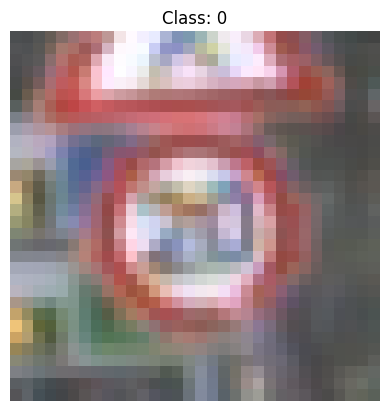

In [13]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.permute(1,2,0))
plt.title(f"Class: {label}")
plt.axis("off")
plt.show()

Create DataLoader

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
# 64 = no of images, 3 = RGB, 32 = height, 32 = width

torch.Size([64, 3, 32, 32])
torch.Size([64])


Build First CNN

In [15]:
import torch
import torch.nn as nn

class TrafficSignCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 43)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Create the Model

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TrafficSignCNN().to(device)

print(model)

TrafficSignCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, in

Test One Forward Pass

In [17]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([64, 43])


Loss Function → Measures how wrong the prediction is.

Optimizer → Updates the weights to reduce the loss.

In [18]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


Training Loop

In [19]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/10], Loss: 0.7352
Epoch [2/10], Loss: 0.0970
Epoch [3/10], Loss: 0.0530
Epoch [4/10], Loss: 0.0381
Epoch [5/10], Loss: 0.0322
Epoch [6/10], Loss: 0.0247
Epoch [7/10], Loss: 0.0255
Epoch [8/10], Loss: 0.0249
Epoch [9/10], Loss: 0.0194
Epoch [10/10], Loss: 0.0236


create a validation split from the training data

In [20]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

Validation Accuracy

In [21]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")



Validation Accuracy: 99.85%


In [22]:
torch.save(model.state_dict(), "traffic_sign_cnn.pth")

In [23]:
class_names = train_dataset.dataset.classes
print(class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


evaluating on the official Test dataset

In [24]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import os

test_csv = os.path.join(path, "Test.csv")

df = pd.read_csv(test_csv)

print(df.head())
print(df.columns)

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png
Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='object')


In [26]:
class_to_idx = train_dataset.dataset.class_to_idx

print(class_to_idx)

{'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}


In [27]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os

class GTSRBTestDataset(Dataset):

    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.root_dir,
            self.data.iloc[idx]["Path"]
        )

        image = Image.open(img_path).convert("RGB")

        label = int(self.data.iloc[idx]["ClassId"])
        label = class_to_idx[str(label)]

        if self.transform:
            image = self.transform(image)

        return image, label

In [28]:
test_csv = os.path.join(path, "Test.csv")

test_dataset = GTSRBTestDataset(
    csv_file=test_csv,
    root_dir=path,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Test Images:", len(test_dataset))

Test Images: 12630


In [29]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Official Test Accuracy: {test_accuracy:.2f}%")

Official Test Accuracy: 97.02%


In [30]:
torch.save(model.state_dict(), "traffic_sign_cnn.pth")

In [31]:
import json

with open("class_mapping.json", "w") as f:
    json.dump(class_to_idx, f)

### Build a Single Image Prediction System ###

Load the Trained Model

In [33]:
import torch
import torch.nn as nn

class TrafficSignCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 43)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Predict One Image

In [50]:
import os

test_image = os.path.join(
    path,
    "Test",
    "00025.png"
)

print(test_image)

C:\Users\raiar\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1\Test\00025.png


In [51]:
img_path = test_image

In [52]:
from PIL import Image

img_path

image = Image.open(img_path).convert("RGB")

image_tensor = transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

Run Prediction

In [49]:
with torch.no_grad():

    outputs = model(image_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, prediction = torch.max(
        probabilities,
        dim=1
    )

print("Predicted Class:", prediction.item())
print("Confidence:", confidence.item()*100)

Predicted Class: 1
Confidence: 100.0


Show the Image

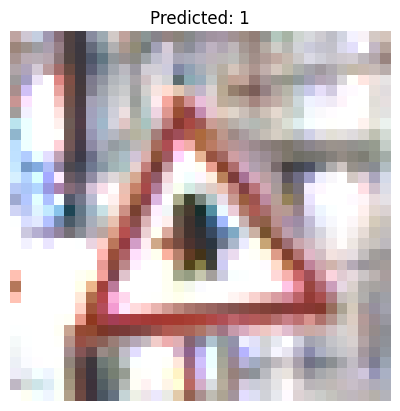

In [53]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(
    f"Predicted: {prediction.item()}"
)
plt.axis("off")
plt.show()

In [54]:
CLASS_NAMES = {
0: "Speed limit 20",
1: "Speed limit 30",
2: "Speed limit 50",
3: "Speed limit 60",
4: "Speed limit 70",
5: "Speed limit 80",
# ...
42: "End no passing"
}

In [55]:
print(
    CLASS_NAMES[prediction.item()]
)

Speed limit 30


Create a Reusable Function

In [58]:
from PIL import Image
import torch

def predict_image(img_path):

    image = Image.open(img_path).convert("RGB")

    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    print(
        f"Prediction: {prediction.item()}"
    )

    print(
        f"Confidence: {confidence.item()*100:.2f}%"
    )

    return prediction.item()

In [60]:
predict_image(
    os.path.join(path, "Test", "00025.png")
)

Prediction: 3
Confidence: 100.00%


3

#### Turn CNN into a real-time traffic sign recognizer using webcam

In [61]:
pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 2.4 MB/s eta 0:00:17
   - -------------------------------------- 1.8/40.2 MB 4.0 MB/s eta 0:00:10
   --- ------------------------------------ 3.1/40.2 MB 4.6 MB/s eta 0:00:09
   ---- ----------------------------------- 4.2/40.2 MB 4.6 MB/s eta 0:00:08
   ----- ---------------------------------- 5.2/40.2 MB 4.7 MB/s eta 0:00:08
   ------ --------------------------------- 6.3/40.2 MB 4.9 MB/s eta 0:00:07
   ------- -------------------------------- 7.9/40.2 MB 5.1 MB/s eta 0:00:07
   -------- ------------------------------- 8.7/40.2 MB 5.0 MB/s eta 0:00:07
   --------- ------------------------------ 9.7/40.2 MB 5.0 MB/s eta 0:00:07
   ---------- ----------------------------- 10.5/40.2 MB 5.0 MB/s eta 0:00:06
   ----------- ---------------------------- 11.3/40.2 MB 4.8 MB/s eta 0:00:07
   --------

In [86]:
CLASS_NAMES = {
    0: "Speed Limit 20 km/h",
    1: "Speed Limit 30 km/h",
    2: "Speed Limit 50 km/h",
    3: "Speed Limit 60 km/h",
    4: "Speed Limit 70 km/h",
    5: "Speed Limit 80 km/h",
    14: "Stop",
    17: "No Entry",
    33: "Turn Right Ahead",
    38: "Keep Right"
}

In [84]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

In [99]:
CLASS_NAMES = {
    0: "Speed Limit 20",
    1: "Speed Limit 30",
    2: "Speed Limit 50",
    3: "Speed Limit 60",
    4: "Speed Limit 70",
    # add all classes...
}

sign_name = CLASS_NAMES.get(prediction.item(), "Unknown")

text = f"{sign_name} ({confidence.item()*100:.1f}%)"

In [100]:
if sign_name == "Stop":
    warning = "STOP AHEAD"

elif sign_name == "Speed Limit 50 km/h":
    warning = "MAX SPEED 50"

elif sign_name == "No Entry":
    warning = "DO NOT ENTER"

open webcam


In [91]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    cv2.imshow("Webcam", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Run CNN on Each Frame

In [97]:
import cv2
from PIL import Image
import torch

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    image = Image.fromarray(rgb)

    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(image_tensor)

        probs = torch.softmax(outputs, dim=1)

        confidence, prediction = torch.max(probs, dim=1)

    text = f"Class: {prediction.item()}  Conf: {confidence.item()*100:.1f}%"

    cv2.putText(
        frame,
        text,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.imshow("Traffic Sign Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Streamlit

In [67]:
pip install streamlit

  Using cached streamlit-1.58.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached altair-6.2.1-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.1.4-py3-none-any.whl.metadata (5.5 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached uvicorn-0.49.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Usi

Upgrading the streamlit app


In [104]:
import streamlit as st

In [105]:
st.progress(confidence.item())

2026-06-12 00:32:25.144 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:25.452 
  command:

    streamlit run c:\Users\raiar\.conda\envs\test\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-12 00:32:25.452 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:25.452 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [106]:
st.metric(
    label="Confidence",
    value=f"{confidence.item()*100:.2f}%"
)

st.progress(float(confidence.item()))

2026-06-12 00:32:26.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:26.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:26.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:26.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:26.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:26.938 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [107]:
probs = torch.softmax(outputs, dim=1)

top_probs, top_classes = torch.topk(probs, k=3)

st.subheader("Top 3 Predictions")

for i in range(3):

    class_id = top_classes[0][i].item()

    prob = top_probs[0][i].item() * 100

    st.write(
        f"{i+1}. {CLASS_NAMES.get(class_id, class_id)} - {prob:.2f}%"
    )

2026-06-12 00:32:46.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:46.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:46.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:46.058 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:46.058 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:46.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:46.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:32:46.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [108]:
import pandas as pd

chart_df = pd.DataFrame({
    "Class": [
        CLASS_NAMES.get(c.item(), c.item())
        for c in top_classes[0]
    ],
    "Probability": [
        p.item()*100
        for p in top_probs[0]
    ]
})

st.bar_chart(
    chart_df.set_index("Class")
)

2026-06-12 00:32:56.002 Serialization of dataframe to Arrow table was unsuccessful. Applying automatic fixes for column types to make the dataframe Arrow-compatible.
Traceback (most recent call last):
  File "c:\Users\raiar\.conda\envs\test\lib\site-packages\streamlit\dataframe_util.py", line 961, in convert_pandas_df_to_arrow_bytes
    table = pa.Table.from_pandas(df)
  File "pyarrow/table.pxi", line 4768, in pyarrow.lib.Table.from_pandas
  File "c:\Users\raiar\.conda\envs\test\lib\site-packages\pyarrow\pandas_compat.py", line 651, in dataframe_to_arrays
    arrays = [convert_column(c, f)
  File "c:\Users\raiar\.conda\envs\test\lib\site-packages\pyarrow\pandas_compat.py", line 651, in <listcomp>
    arrays = [convert_column(c, f)
  File "c:\Users\raiar\.conda\envs\test\lib\site-packages\pyarrow\pandas_compat.py", line 639, in convert_column
    raise e
  File "c:\Users\raiar\.conda\envs\test\lib\site-packages\pyarrow\pandas_compat.py", line 633, in convert_column
    result = pa.array

DeltaGenerator()

In [109]:
st.sidebar.title("Project Info")

st.sidebar.write("Model: Custom CNN")
st.sidebar.write("Dataset: GTSRB")
st.sidebar.write("Classes: 43")
st.sidebar.write("Test Accuracy: 97.28%")
st.sidebar.write("Framework: PyTorch")

2026-06-12 00:33:00.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:33:00.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:33:00.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:33:00.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:33:00.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:33:00.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:33:00.856 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 00:33:00.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [110]:
import torch

# Replace 'model' with the variable name of your trained network
torch.save(model.state_dict(), "model.pth")